In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mjawad17/world-of-warships-ship-performance-stats")

print("Path to dataset files:", path)

100%|██████████| 93.8k/93.8k [00:00<00:00, 35.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mjawad17/world-of-warships-ship-performance-stats/versions/3


In [3]:
files = os.listdir(path)
print("Files in downloaded directory:", files)

csv_file_name = [f for f in files if f.endswith('.csv')][0] # Get the CSV
df = pd.read_csv(os.path.join(path, csv_file_name))

display(df.head())

Files in downloaded directory: ['wows_ship_stats.csv', 'wows_ship_stats.json']


,Ship,Tier,Class,Nation,Players,Battles,Base XP,Damage,Frags,Win rate,Capture,Defence,Spotting,Potential,Aircraft,Survival rate
0,Patrie,11,BB,France,9092,337170,1388,125865,0.936,0.512,2.13,4.74,19358,1809099,5.60,0.426
1,Hannover,11,BB,Germany,16503,319701,1150,86471,0.633,0.485,1.81,4.16,20080,1930510,6.42,0.240
2,Satsuma,11,BB,Japan,40417,1562549,1246,112667,0.809,0.499,1.32,3.21,17402,1730502,4.15,0.469
3,Devastation,11,BB,U.K.,5660,140172,1323,127807,0.766,0.499,1.98,4.78,20776,1896948,4.71,0.499
4,Maine,11,BB,U.S.A.,10744,352970,1344,114812,0.890,0.513,2.32,4.11,22194,2078203,7.70,0.445


In [4]:
# Strip whitespace in string columns
df['Ship'] = df['Ship'].str.strip()
df['Class'] = df['Class'].str.strip()
df['Nation'] = df['Nation'].str.strip()

# Convert relevant columns to numeric
numeric_cols = ['Players','Battles','Base XP','Damage','Frags','Win rate',
                'Capture','Defence','Spotting','Potential','Aircraft','Survival rate']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaNs with 0 for modeling purposes
df[numeric_cols] = df[numeric_cols].fillna(0)

# Remove duplicates
df.drop_duplicates(inplace=True)

df.shape


(925, 16)

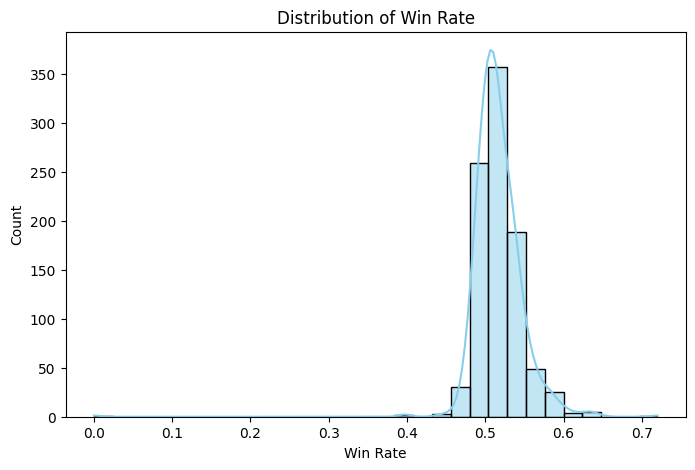

Mean Win Rate: 0.5166994594594595
Median Win Rate: 0.513
Win Rate Range: 0.0 → 0.72


In [5]:
# 3.1 Win Rate Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Win rate'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Win Rate")
plt.xlabel("Win Rate")
plt.ylabel("Count")
plt.show()

print("Mean Win Rate:", df['Win rate'].mean())
print("Median Win Rate:", df['Win rate'].median())
print("Win Rate Range:", df['Win rate'].min(), "→", df['Win rate'].max())

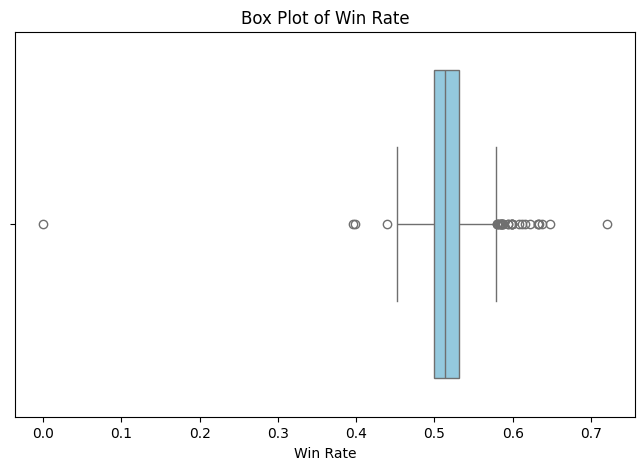

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Win rate'], color='skyblue')
plt.title('Box Plot of Win Rate')
plt.xlabel('Win Rate')
plt.ylabel('')
plt.show()

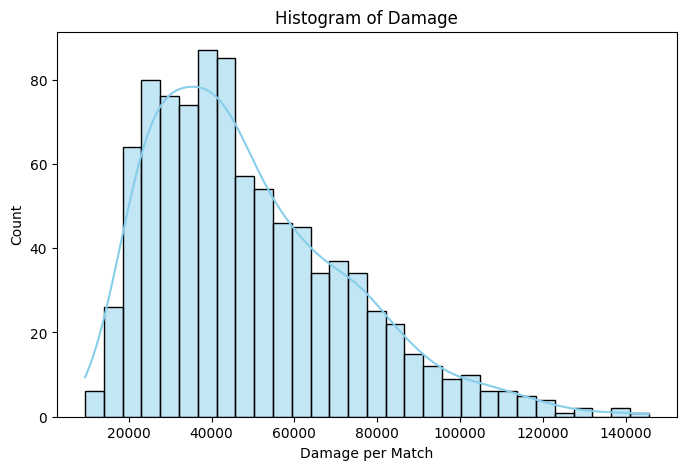

Mean Damage: 49264.18702702703
Damage Range: 9487 → 145521


In [7]:
# Damage Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Damage'], bins=30, kde=True, color='skyblue')
plt.title("Histogram of Damage")
plt.xlabel("Damage per Match")
plt.ylabel("Count")
plt.show()

print("Mean Damage:", df['Damage'].mean())
print("Damage Range:", df['Damage'].min(), "→", df['Damage'].max())

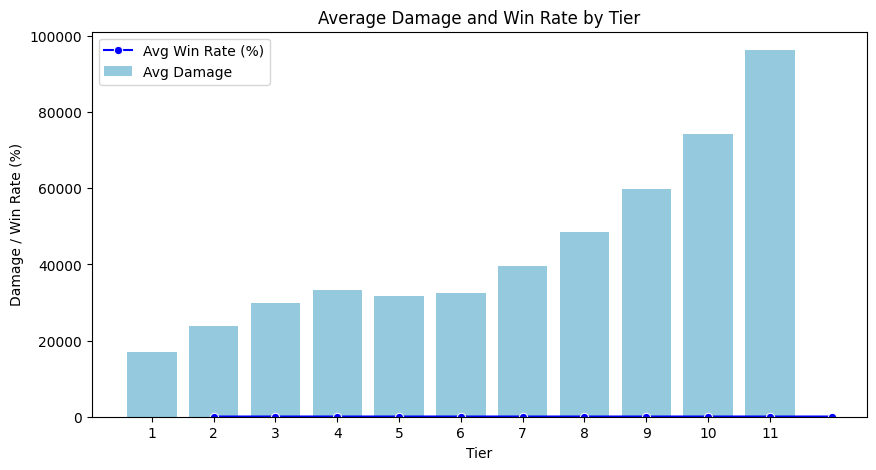

Ship counts by Tier:
 Tier
1      13
2      29
3      39
4      43
5      71
6      97
7     112
8     185
9     153
10    162
11     21
Name: count, dtype: int64


In [8]:
tier_counts = df['Tier'].value_counts().sort_index()
tier_avg = df.groupby('Tier')[['Damage','Win rate']].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=tier_avg.index, y=tier_avg['Damage'], color='skyblue', label='Avg Damage')
sns.lineplot(x=tier_avg.index, y=tier_avg['Win rate']*100, marker='o', color='blue', label='Avg Win Rate (%)')
plt.title("Average Damage and Win Rate by Tier")
plt.xlabel("Tier")
plt.ylabel("Damage / Win Rate (%)")
plt.legend()
plt.show()

print("Ship counts by Tier:\n", tier_counts)

/tmp/ipykernel_1171/1361189274.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_avg.index, y=class_avg.values, palette='pastel')


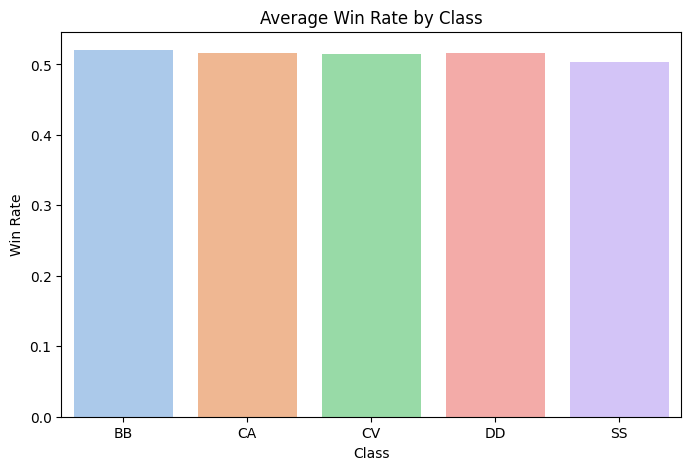

Ship counts by class:
 Class
CA    351
BB    250
DD    226
CV     69
SS     29
Name: count, dtype: int64


In [9]:
class_counts = df['Class'].value_counts()
class_avg = df.groupby('Class')['Win rate'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=class_avg.index, y=class_avg.values, palette='pastel')
plt.title("Average Win Rate by Class")
plt.ylabel("Win Rate")
plt.show()

print("Ship counts by class:\n", class_counts)

/tmp/ipykernel_1171/817211121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nation_counts.index, y=nation_counts.values, palette='muted')


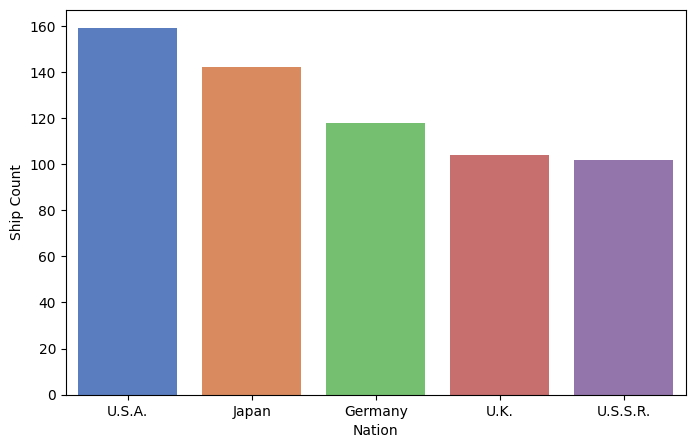

Top 5 nations by ship count:
 Nation
U.S.A.      159
Japan       142
Germany     118
U.K.        104
U.S.S.R.    102
Name: count, dtype: int64


In [10]:
nation_counts = df['Nation'].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=nation_counts.index, y=nation_counts.values, palette='muted')
plt.ylabel("Ship Count")
plt.show()

print("Top 5 nations by ship count:\n", nation_counts)

/tmp/ipykernel_1171/1854917932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_nation_counts.index, y=all_nation_counts.values, palette='viridis')


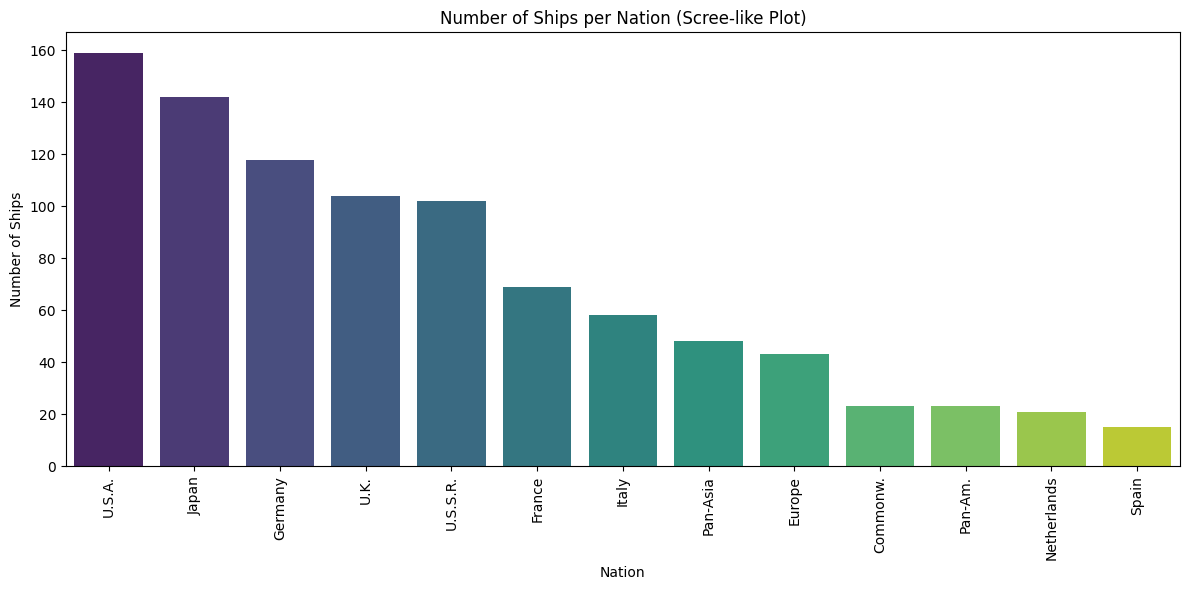

Number of ships per Nation:
 Nation
U.S.A.         159
Japan          142
Germany        118
U.K.           104
U.S.S.R.       102
France          69
Italy           58
Pan-Asia        48
Europe          43
Commonw.        23
Pan-Am.         23
Netherlands     21
Spain           15
Name: count, dtype: int64


In [11]:
all_nation_counts = df['Nation'].value_counts() # Get counts for all nations, already sorted descending

plt.figure(figsize=(12, 6))
sns.barplot(x=all_nation_counts.index, y=all_nation_counts.values, palette='viridis')
plt.title('Number of Ships per Nation (Scree-like Plot)')
plt.xlabel('Nation')
plt.ylabel('Number of Ships')
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout()
plt.show()

print("Number of ships per Nation:\n", all_nation_counts)

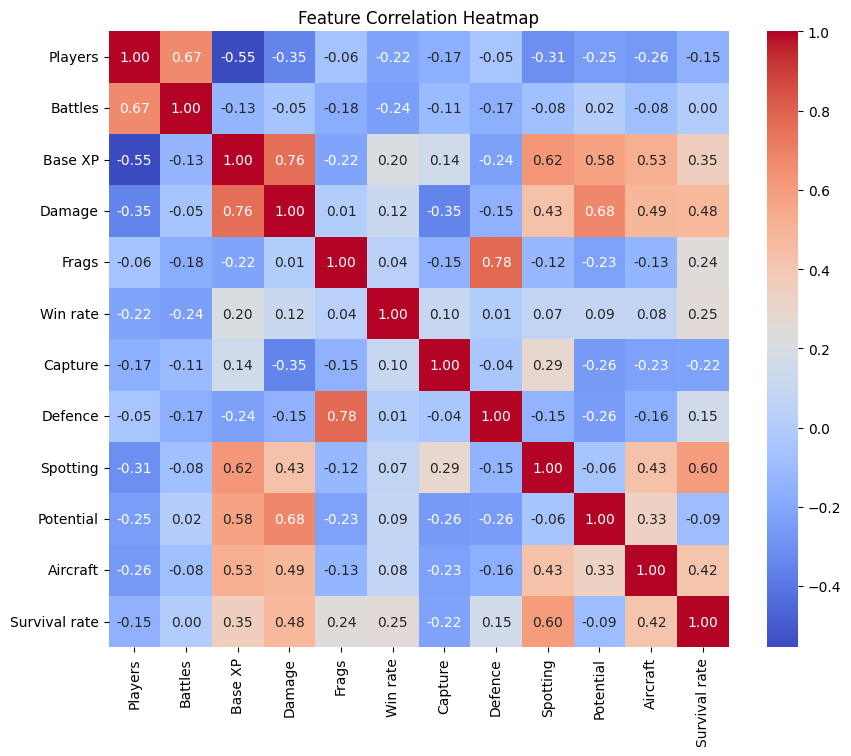

Pearson correlation with Win Rate:
 Win rate         1.000000
Survival rate    0.250668
Base XP          0.203173
Damage           0.115972
Capture          0.102465
Potential        0.085567
Aircraft         0.081621
Spotting         0.074188
Frags            0.035328
Defence          0.006153
Players         -0.217937
Battles         -0.239653
Name: Win rate, dtype: float64


In [12]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

print("Pearson correlation with Win Rate:\n", corr_matrix['Win rate'].sort_values(ascending=False))


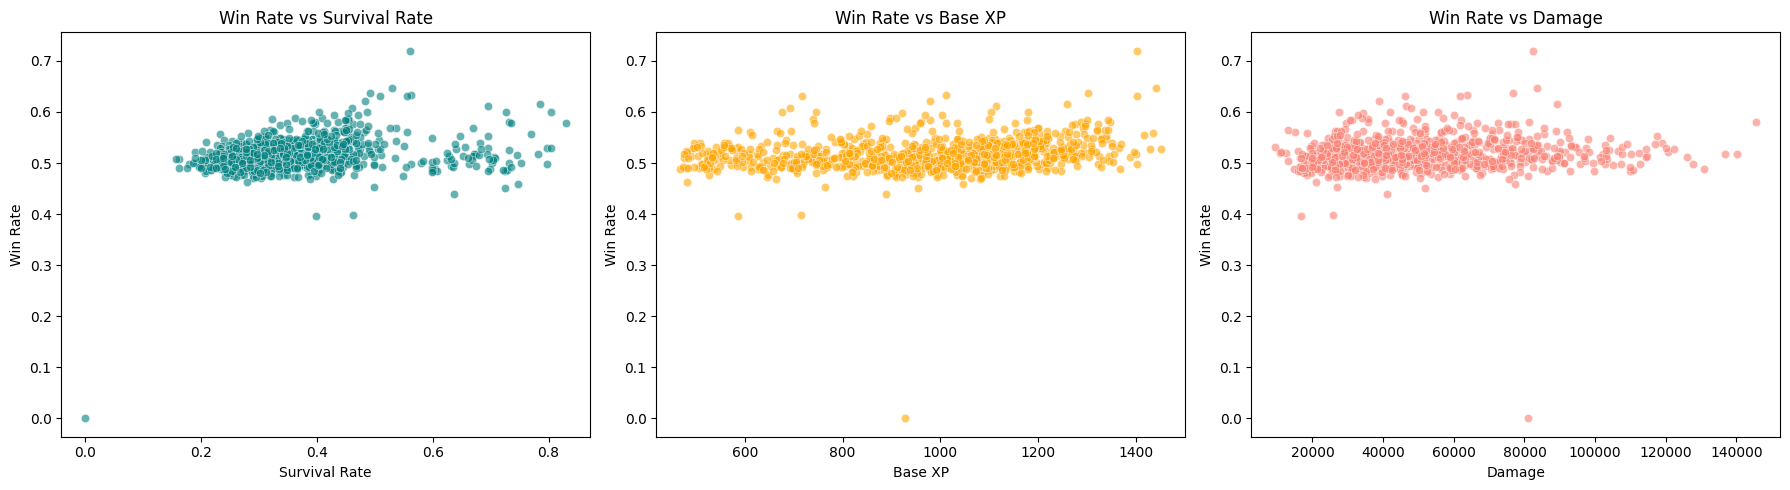

In [13]:

plt.figure(figsize=(18,5))

# 1. Win Rate vs Survival Rate
plt.subplot(1, 3, 1)
sns.scatterplot(x='Survival rate', y='Win rate', data=df, color='teal', alpha=0.6)
plt.title("Win Rate vs Survival Rate")
plt.xlabel("Survival Rate")
plt.ylabel("Win Rate")

# 2. Win Rate vs Base XP
plt.subplot(1, 3, 2)
sns.scatterplot(x='Base XP', y='Win rate', data=df, color='orange', alpha=0.6)
plt.title("Win Rate vs Base XP")
plt.xlabel("Base XP")
plt.ylabel("Win Rate")

# 3. Win Rate vs Damage
plt.subplot(1, 3, 3)
sns.scatterplot(x='Damage', y='Win rate', data=df, color='salmon', alpha=0.6)
plt.title("Win Rate vs Damage")
plt.xlabel("Damage")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.show()

Explained variance (first 3 PCs): [0.37599838 0.22169043 0.17443845]
Cumulative variance: 0.7721272567001812


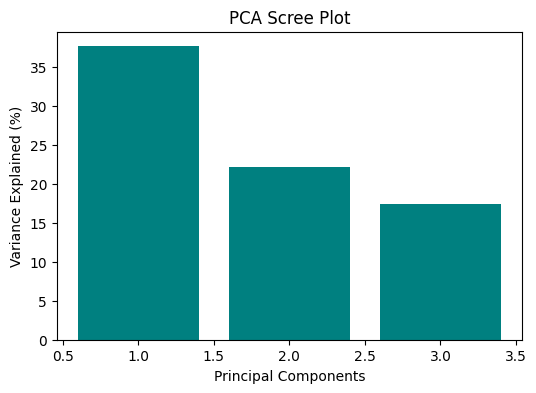

In [16]:
features_for_pca = ['Damage','Frags','Base XP','Capture','Defence','Spotting','Potential','Aircraft','Survival rate']
X = df[features_for_pca]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

print("Explained variance (first 3 PCs):", explained_variance)
print("Cumulative variance:", explained_variance.sum())

# Scree plot
plt.figure(figsize=(6,4))
plt.bar(range(1,4), explained_variance*100, color='teal')
plt.ylabel("Variance Explained (%)")
plt.xlabel("Principal Components")
plt.title("PCA Scree Plot")
plt.show()

In [17]:
pca_loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=features_for_pca)
display(pca_loadings)

,PC1,PC2,PC3
Damage,0.475536,0.120655,-0.229115
Frags,-0.140899,0.608421,-0.110273
Base XP,0.481665,-0.045079,0.112776
Capture,-0.086476,-0.193150,0.615154
Defence,-0.188381,0.564317,-0.048410
Spotting,0.358215,0.124211,0.529195
Potential,0.328866,-0.201008,-0.471318
Aircraft,0.394222,0.077910,-0.024734
Survival rate,0.295237,0.442233,0.197661


In [18]:
y = df['Win rate']
X = df[features_for_pca]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

# Feature impact
lr_coef = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print("Linear Regression Coefficients:\n", lr_coef)

Linear Regression R²: -0.14668484858974895
MAE: 0.020203202497443506
MSE: 0.0006897060988091608
Linear Regression Coefficients:
 Survival rate    2.231996e-01
Capture          8.927335e-04
Base XP          5.284923e-05
Potential        1.395284e-08
Damage          -3.807185e-07
Spotting        -1.128056e-06
Defence         -1.406134e-04
Aircraft        -9.654705e-04
Frags           -8.863913e-03
dtype: float64


In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest R²: 0.6059712847586771
MAE: 0.010483165467625906
MSE: 0.0002369997374100719


In [21]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:\n", rf_importance)

Random Forest Feature Importance:
 Frags            0.326964
Defence          0.145547
Capture          0.144307
Survival rate    0.131615
Base XP          0.096126
Spotting         0.052609
Potential        0.037272
Damage           0.033589
Aircraft         0.031971
dtype: float64


In [22]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

y_pred_nn = model.predict(X_test).flatten()

print("Neural Network R²:", r2_score(y_test, y_pred_nn))
print("MAE:", mean_absolute_error(y_test, y_pred_nn))
print("MSE:", mean_squared_error(y_test, y_pred_nn))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Neural Network R²: -38980912.40372091
MAE: 129.95106751572314
MSE: 23446.175071348564


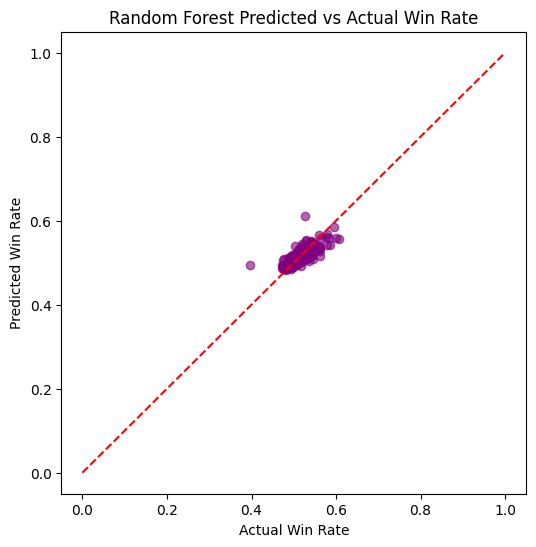

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple')
plt.plot([0,1],[0,1], 'r--')
plt.xlabel("Actual Win Rate")
plt.ylabel("Predicted Win Rate")
plt.title("Random Forest Predicted vs Actual Win Rate")
plt.show()